In [1]:
import pandas as pd
import numpy as np
from PIL import Image
from pathlib import Path

DATA_ROOT = Path("/kaggle/input/datasets/esayasmelaku/solar-flare-boucheron-c1-224")

for item in DATA_ROOT.iterdir():
    print(item)

labels_csv = DATA_ROOT / "Lat60_Lon60_Nans0_C1.0_24hr_png_224_features.csv"
df = pd.read_csv(labels_csv, header=None)
print(df.shape)
print(df.head())

df.columns = [f"feature_{i}" for i in range(29)] + ["label", "flare_size", "filename"]
print(df["label"].value_counts())

/kaggle/input/datasets/esayasmelaku/solar-flare-boucheron-c1-224/List_of_AR_in_Train_Data_by_AR.csv
/kaggle/input/datasets/esayasmelaku/solar-flare-boucheron-c1-224/List_of_AR_in_Validation_data_by_AR.csv
/kaggle/input/datasets/esayasmelaku/solar-flare-boucheron-c1-224/README.md
/kaggle/input/datasets/esayasmelaku/solar-flare-boucheron-c1-224/List_of_AR_in_Test_Data_by_AR.csv
/kaggle/input/datasets/esayasmelaku/solar-flare-boucheron-c1-224/Lat60_Lon60_Nans0_C1.0_24hr_png_224_features.csv
/kaggle/input/datasets/esayasmelaku/solar-flare-boucheron-c1-224/Validation_Data_by_AR_png_224.csv
/kaggle/input/datasets/esayasmelaku/solar-flare-boucheron-c1-224/Lat60_Lon60_Nans0_png_224
/kaggle/input/datasets/esayasmelaku/solar-flare-boucheron-c1-224/Train_Data_by_AR_png_224.csv
/kaggle/input/datasets/esayasmelaku/solar-flare-boucheron-c1-224/Test_Data_by_AR_png_224.csv
/kaggle/input/datasets/esayasmelaku/solar-flare-boucheron-c1-224/C1.0_24hr_224_png_Labels.txt
(950047, 32)
         0         1   

label
0    759465
1    190582
Name: count, dtype: int64
label
0    79.94
1    20.06
Name: count, dtype: float64


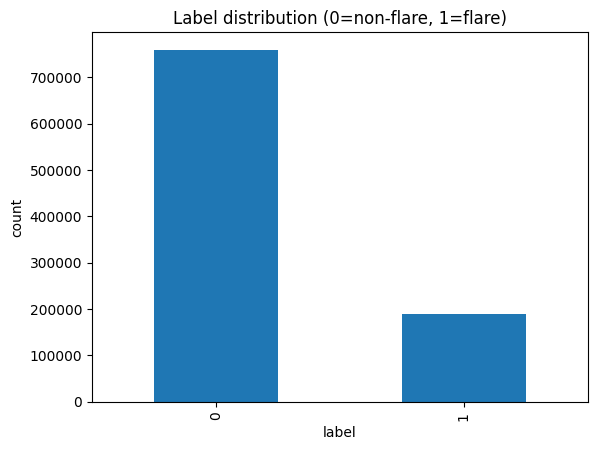

Number of unique ARs: 1570
count    1570.000000
mean      605.125478
std       316.406007
min         3.000000
25%       335.250000
50%       633.500000
75%       915.000000
max      1080.000000
dtype: float64


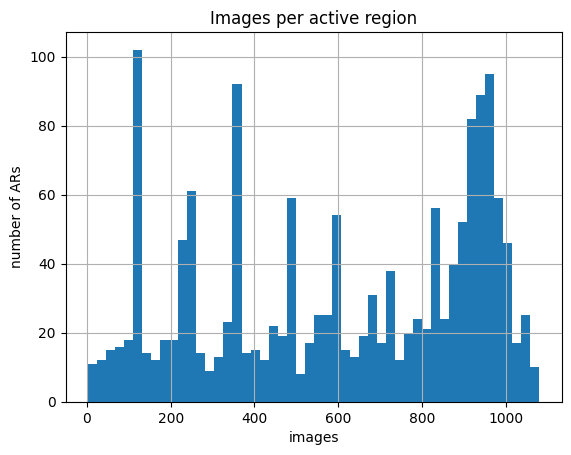

  AR_number    timestamp_str
0      1064  20100501_000000
1      1064  20100501_001200
2      1064  20100501_002400
3      1064  20100501_003600
4      1064  20100501_004800
5      1064  20100501_010000
6      1064  20100501_011200
7      1064  20100501_012400
8      1064  20100501_013600
9      1064  20100501_014800


In [2]:
import matplotlib.pyplot as plt

# --- Class balance ---
counts = df["label"].value_counts()
print(counts)
print((counts / counts.sum() * 100).round(2))

plt.figure()
counts.plot(kind="bar")
plt.title("Label distribution (0=non-flare, 1=flare)")
plt.xlabel("label"); plt.ylabel("count")
plt.show()

# --- Extract AR number from filename (first part before underscore) ---
df["AR_number"] = df["filename"].str.split("_").str[0]
per_ar = df.groupby("AR_number").size()
print("Number of unique ARs:", len(per_ar))
print(per_ar.describe())

plt.figure()
per_ar.hist(bins=50)
plt.title("Images per active region")
plt.xlabel("images"); plt.ylabel("number of ARs")
plt.show()

# --- Extract timestamp from filename for temporal check ---
df["timestamp_str"] = df["filename"].str.extract(r"(\d{8}_\d{6})")
print(df[["AR_number", "timestamp_str"]].head(10))

In [3]:
IMAGE_ROOT_REAL = DATA_ROOT / "Lat60_Lon60_Nans0_png_224" / "Lat60_Lon60_Nans0_png_224"

sample_row = df.iloc[0]
sample_path = IMAGE_ROOT_REAL / sample_row["AR_number"] / sample_row["filename"]
print("Testing path:", sample_path)
print("Exists:", sample_path.exists())

if sample_path.exists():
    img = Image.open(sample_path)
    arr = np.array(img)
    print("Size:", img.size, "Mode:", img.mode, "dtype:", arr.dtype)
    print("Min:", arr.min(), "Max:", arr.max(), "Mean:", arr.mean())

Testing path: /kaggle/input/datasets/esayasmelaku/solar-flare-boucheron-c1-224/Lat60_Lon60_Nans0_png_224/Lat60_Lon60_Nans0_png_224/1064/1064_hmi.M_720s.20100501_000000_TAI.1.magnetogram_224.png
Exists: True
Size: (224, 224) Mode: L dtype: uint8
Min: 70 Max: 172 Mean: 127.51094148596938


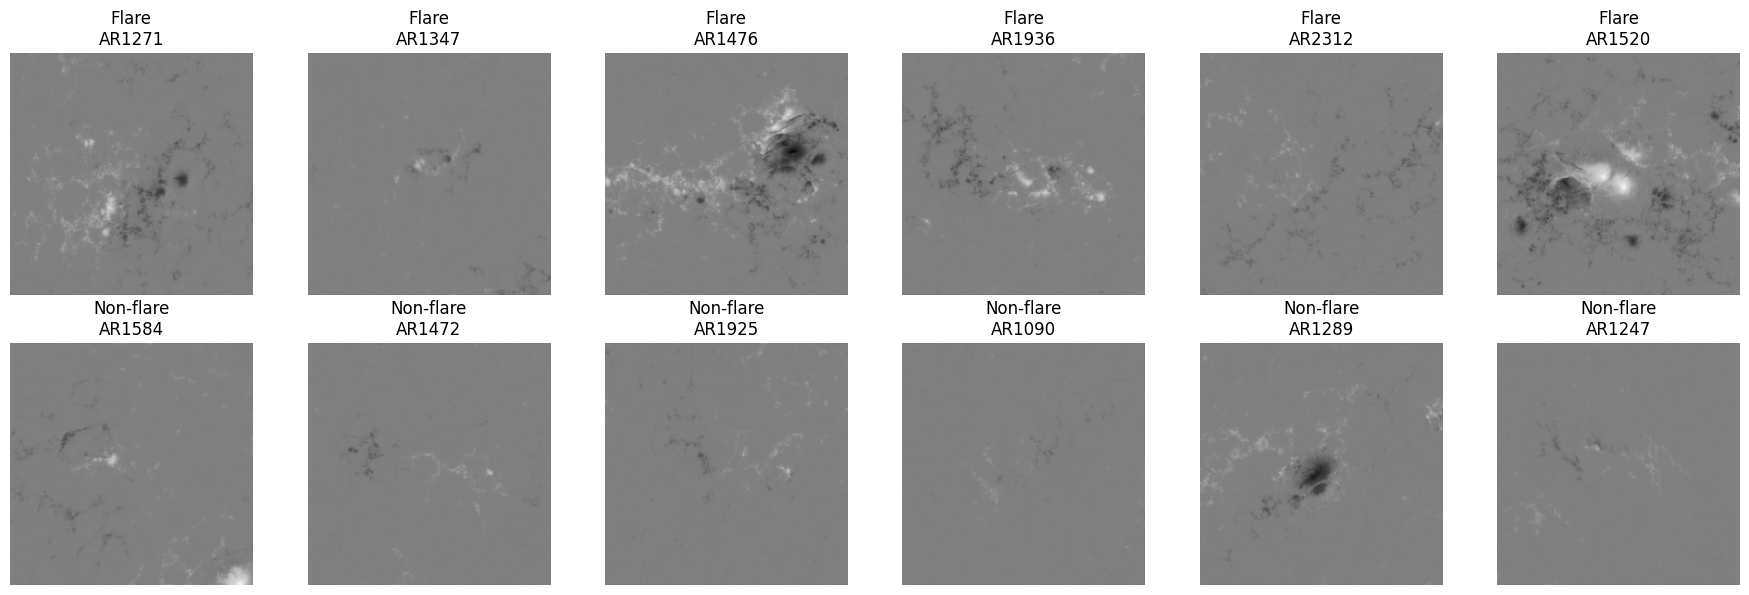

In [4]:
import matplotlib.pyplot as plt

def get_image_path(row):
    return IMAGE_ROOT_REAL / row["AR_number"] / row["filename"]

# Sample 6 flare and 6 non-flare images
flare_sample = df[df["label"] == 1].sample(6, random_state=1)
nonflare_sample = df[df["label"] == 0].sample(6, random_state=1)

fig, axes = plt.subplots(2, 6, figsize=(18, 6))
for i, (_, row) in enumerate(flare_sample.iterrows()):
    p = get_image_path(row)
    img = np.array(Image.open(p))
    axes[0, i].imshow(img, cmap="gray", vmin=0, vmax=255)
    axes[0, i].set_title(f"Flare\nAR{row['AR_number']}")
    axes[0, i].axis("off")

for i, (_, row) in enumerate(nonflare_sample.iterrows()):
    p = get_image_path(row)
    img = np.array(Image.open(p))
    axes[1, i].imshow(img, cmap="gray", vmin=0, vmax=255)
    axes[1, i].set_title(f"Non-flare\nAR{row['AR_number']}")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

In [5]:
import hashlib
from collections import defaultdict

# Sample 300 images for corruption/duplicate check (checking all 950k would take too long)
check_sample = df.sample(300, random_state=42)

corrupted = []
hashes = defaultdict(list)

for _, row in check_sample.iterrows():
    p = get_image_path(row)
    if not p.exists():
        corrupted.append((str(p), "missing"))
        continue
    try:
        Image.open(p).verify()
        with open(p, "rb") as f:
            h = hashlib.md5(f.read()).hexdigest()
        hashes[h].append(str(p))
    except Exception as e:
        corrupted.append((str(p), str(e)))

print(f"Corrupted/missing in sample of 300: {len(corrupted)}")
dupes = {h: paths for h, paths in hashes.items() if len(paths) > 1}
print(f"Duplicate groups found: {len(dupes)}")

# --- AR-level leakage check: does the official split avoid overlap? ---
train_ar = pd.read_csv(DATA_ROOT / "List_of_AR_in_Train_Data_by_AR.csv", header=None)
val_ar = pd.read_csv(DATA_ROOT / "List_of_AR_in_Validation_data_by_AR.csv", header=None)
test_ar = pd.read_csv(DATA_ROOT / "List_of_AR_in_Test_Data_by_AR.csv", header=None)

train_ids = set(train_ar[0].astype(str))
val_ids = set(val_ar[0].astype(str))
test_ids = set(test_ar[0].astype(str))

print("Train ARs:", len(train_ids), "Val ARs:", len(val_ids), "Test ARs:", len(test_ids))
print("Train∩Val overlap:", train_ids & val_ids)
print("Train∩Test overlap:", train_ids & test_ids)
print("Val∩Test overlap:", val_ids & test_ids)

Corrupted/missing in sample of 300: 0
Duplicate groups found: 0
Train ARs: 1256 Val ARs: 157 Test ARs: 157
Train∩Val overlap: set()
Train∩Test overlap: set()
Val∩Test overlap: set()


In [6]:
report = f"""
BOUCHERON SOLAR FLARE DATASET — FINAL DATA REPORT
==================================================

SOURCE
Boucheron, Vincent, Grajeda, Wuest (New Mexico State University)
Labels/metadata DOI: 10.5061/dryad.jq2bvq898
Images DOI: 10.5281/zenodo.7775776
Paper: arxiv.org/abs/2305.09492
Permanent Kaggle Dataset: esayasmelaku/solar-flare-boucheron-c1-224

DATASET SUMMARY
Active regions: 1,570
Total images: 950,047
Image size: 224x224, grayscale (mode L), uint8
Date range: May 2010 - Dec 2018 (per README)
Label: 1 = GOES flare >C1.0 within 24hrs after image, 0 = no such flare
Class balance: 79.94% non-flare (759,465), 20.06% flare (190,582)
Images per AR: min 3, max 1080, mean ~605

DATA QUALITY (sample of 300 images)
Corrupted/missing: 0
Duplicates: 0

OFFICIAL SPLIT (verified, not assumed)
Train ARs: 1256, Val ARs: 157, Test ARs: 157
AR-level overlap between splits: NONE (verified via set intersection)
Conclusion: official split is leakage-safe at the AR level

TEMPORAL STRUCTURE
Filenames confirmed to include NOAA AR number and exact timestamp
(e.g. 1064_hmi.M_720s.20100501_000000_TAI...), cadence ~720 seconds (12 min),
consistent with README's stated acquisition cadence.

ML IMPLICATIONS
- Use the authors' official AR-level split (Train/Validation/Test_Data_by_AR_png_224.csv)
  rather than a random image-level split, to avoid leakage.
- 20%/80% class imbalance likely needs class weighting or resampling during training.
- Temporal modeling (CNN+GRU/LSTM per AR sequence) is feasible: real, evenly-spaced
  timestamped sequences exist per AR (confirmed, not assumed).
- Recommended next step: build a baseline single-frame CNN using the official split
  first, establish a benchmark, then evaluate whether adding temporal modeling improves
  on it — consistent with van der Sande et al. 2023's finding referenced in the project notes.
"""

print(report)
with open("/kaggle/working/data_report.txt", "w") as f:
    f.write(report)
print("\nReport saved to /kaggle/working/data_report.txt")


BOUCHERON SOLAR FLARE DATASET — FINAL DATA REPORT

SOURCE
Boucheron, Vincent, Grajeda, Wuest (New Mexico State University)
Labels/metadata DOI: 10.5061/dryad.jq2bvq898
Images DOI: 10.5281/zenodo.7775776
Paper: arxiv.org/abs/2305.09492
Permanent Kaggle Dataset: esayasmelaku/solar-flare-boucheron-c1-224

DATASET SUMMARY
Active regions: 1,570
Total images: 950,047
Image size: 224x224, grayscale (mode L), uint8
Date range: May 2010 - Dec 2018 (per README)
Label: 1 = GOES flare >C1.0 within 24hrs after image, 0 = no such flare
Class balance: 79.94% non-flare (759,465), 20.06% flare (190,582)
Images per AR: min 3, max 1080, mean ~605

DATA QUALITY (sample of 300 images)
Corrupted/missing: 0
Duplicates: 0

OFFICIAL SPLIT (verified, not assumed)
Train ARs: 1256, Val ARs: 157, Test ARs: 157
AR-level overlap between splits: NONE (verified via set intersection)
Conclusion: official split is leakage-safe at the AR level

TEMPORAL STRUCTURE
Filenames confirmed to include NOAA AR number and exact t

In [7]:
train_ar = pd.read_csv(DATA_ROOT / "List_of_AR_in_Train_Data_by_AR.csv", header=None)[0].astype(str)
val_ar = pd.read_csv(DATA_ROOT / "List_of_AR_in_Validation_data_by_AR.csv", header=None)[0].astype(str)
test_ar = pd.read_csv(DATA_ROOT / "List_of_AR_in_Test_Data_by_AR.csv", header=None)[0].astype(str)

train_data = df[df["AR_number"].isin(train_ar)]
val_data = df[df["AR_number"].isin(val_ar)]
test_data = df[df["AR_number"].isin(test_ar)]

print("Train:", train_data.shape, "Val:", val_data.shape, "Test:", test_data.shape)

Train: (759357, 34) Val: (95933, 34) Test: (94757, 34)


In [8]:
import numpy as np
from sklearn.preprocessing import StandardScaler

feature_cols = [f"feature_{i}" for i in range(29)]

# --- Missing value check (critical — don't skip) ---
print("Missing values per feature (train set):")
print(train_data[feature_cols].isna().sum())

print("\nMissing values per feature (val set):")
print(val_data[feature_cols].isna().sum())

print("\nMissing values per feature (test set):")
print(test_data[feature_cols].isna().sum())

# --- Check for infinite values too (can silently break SVM training) ---
print("\nInfinite values in train set:", np.isinf(train_data[feature_cols].values).sum())

Missing values per feature (train set):
feature_0     0
feature_1     0
feature_2     0
feature_3     0
feature_4     0
feature_5     0
feature_6     0
feature_7     0
feature_8     0
feature_9     0
feature_10    0
feature_11    0
feature_12    0
feature_13    0
feature_14    0
feature_15    0
feature_16    0
feature_17    0
feature_18    0
feature_19    0
feature_20    0
feature_21    0
feature_22    0
feature_23    0
feature_24    0
feature_25    0
feature_26    0
feature_27    0
feature_28    0
dtype: int64

Missing values per feature (val set):
feature_0     0
feature_1     0
feature_2     0
feature_3     0
feature_4     0
feature_5     0
feature_6     0
feature_7     0
feature_8     0
feature_9     0
feature_10    0
feature_11    0
feature_12    0
feature_13    0
feature_14    0
feature_15    0
feature_16    0
feature_17    0
feature_18    0
feature_19    0
feature_20    0
feature_21    0
feature_22    0
feature_23    0
feature_24    0
feature_25    0
feature_26    0
feature_27  

In [9]:
scaler = StandardScaler()

X_train = scaler.fit_transform(train_data[feature_cols])
X_val = scaler.transform(val_data[feature_cols])
X_test = scaler.transform(test_data[feature_cols])

y_train = train_data["label"].values
y_val = val_data["label"].values
y_test = test_data["label"].values

print("X_train shape:", X_train.shape)
print("X_train mean (should be ~0):", X_train.mean().round(3))
print("X_train std (should be ~1):", X_train.std().round(3))

X_train shape: (759357, 29)
X_train mean (should be ~0): 0.0
X_train std (should be ~1): 0.965


In [10]:
from sklearn.svm import LinearSVC
import time

start = time.time()

svm_model = LinearSVC(
    class_weight="balanced",   # corrects for the 80/20 imbalance
    max_iter=5000,             # LinearSVC sometimes needs more iterations to converge on large data
    random_state=42
)

svm_model.fit(X_train, y_train)

elapsed = time.time() - start
print(f"Training finished in {elapsed/60:.1f} minutes")

Training finished in 0.3 minutes


In [11]:
print("Number of iterations used:", svm_model.n_iter_)
print("Max iterations allowed:", svm_model.max_iter)
print("Coefficient shape:", svm_model.coef_.shape)
print("Intercept:", svm_model.intercept_)

Number of iterations used: 16
Max iterations allowed: 5000
Coefficient shape: (1, 29)
Intercept: [-0.19689937]


In [12]:
from sklearn.metrics import confusion_matrix

val_preds = svm_model.predict(X_val)
print("Prediction distribution:", pd.Series(val_preds).value_counts())
print("\nConfusion matrix:")
print(confusion_matrix(y_val, val_preds))

Prediction distribution: 0    62671
1    33262
Name: count, dtype: int64

Confusion matrix:
[[57830 18312]
 [ 4841 14950]]


In [13]:
TN, FP, FN, TP = confusion_matrix(y_val, val_preds).ravel()

TPR = TP / (TP + FN)   # sensitivity: correctly caught flares
TNR = TN / (TN + FP)   # specificity: correctly caught non-flares

TSS = TPR + TNR - 1

HSS = 2 * (TP*TN - FN*FP) / ((TP+FN)*(FN+TN) + (TP+FP)*(FP+TN))

print(f"TPR (recall on flares): {TPR:.4f}")
print(f"TNR (recall on non-flares): {TNR:.4f}")
print(f"TSS: {TSS:.4f}")
print(f"HSS: {HSS:.4f}")

TPR (recall on flares): 0.7554
TNR (recall on non-flares): 0.7595
TSS: 0.5149
HSS: 0.4113


In [14]:
test_preds = svm_model.predict(X_test)
TN, FP, FN, TP = confusion_matrix(y_test, test_preds).ravel()

TPR = TP / (TP + FN)
TNR = TN / (TN + FP)
TSS = TPR + TNR - 1
HSS = 2 * (TP*TN - FN*FP) / ((TP+FN)*(FN+TN) + (TP+FP)*(FP+TN))

print(f"TEST SET RESULTS")
print(f"TPR: {TPR:.4f}, TNR: {TNR:.4f}")
print(f"TSS: {TSS:.4f}, HSS: {HSS:.4f}")

TEST SET RESULTS
TPR: 0.7821, TNR: 0.7560
TSS: 0.5382, HSS: 0.4427


In [15]:
from sklearn.metrics import confusion_matrix
import numpy as np

# LinearSVC has no predict_proba, but decision_function gives a real-valued score
val_scores = svm_model.decision_function(X_val)

thresholds = np.linspace(val_scores.min(), val_scores.max(), 300)
best_tss, best_thresh = -1, 0.0

for t in thresholds:
    preds = (val_scores >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val, preds).ravel()
    tpr = tp / (tp + fn)
    tnr = tn / (tn + fp)
    tss = tpr + tnr - 1
    if tss > best_tss:
        best_tss, best_thresh = tss, t

print(f"Best threshold (chosen on validation set only): {best_thresh:.4f}")
print(f"Validation TSS at this threshold: {best_tss:.4f}")

# Apply that SAME threshold to test — never re-tune on test data, that would be leakage
test_scores = svm_model.decision_function(X_test)
test_preds_tuned = (test_scores >= best_thresh).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, test_preds_tuned).ravel()
tpr, tnr = tp/(tp+fn), tn/(tn+fp)
tss_tuned = tpr + tnr - 1
hss_tuned = 2*(tp*tn - fn*fp) / ((tp+fn)*(fn+tn) + (tp+fp)*(fp+tn))

print(f"\nTEST SET (threshold tuned on val): TPR={tpr:.4f}, TNR={tnr:.4f}")
print(f"TSS={tss_tuned:.4f}, HSS={hss_tuned:.4f}")

Best threshold (chosen on validation set only): 0.0588
Validation TSS at this threshold: 0.5177

TEST SET (threshold tuned on val): TPR=0.7515, TNR=0.7895
TSS=0.5409, HSS=0.4644


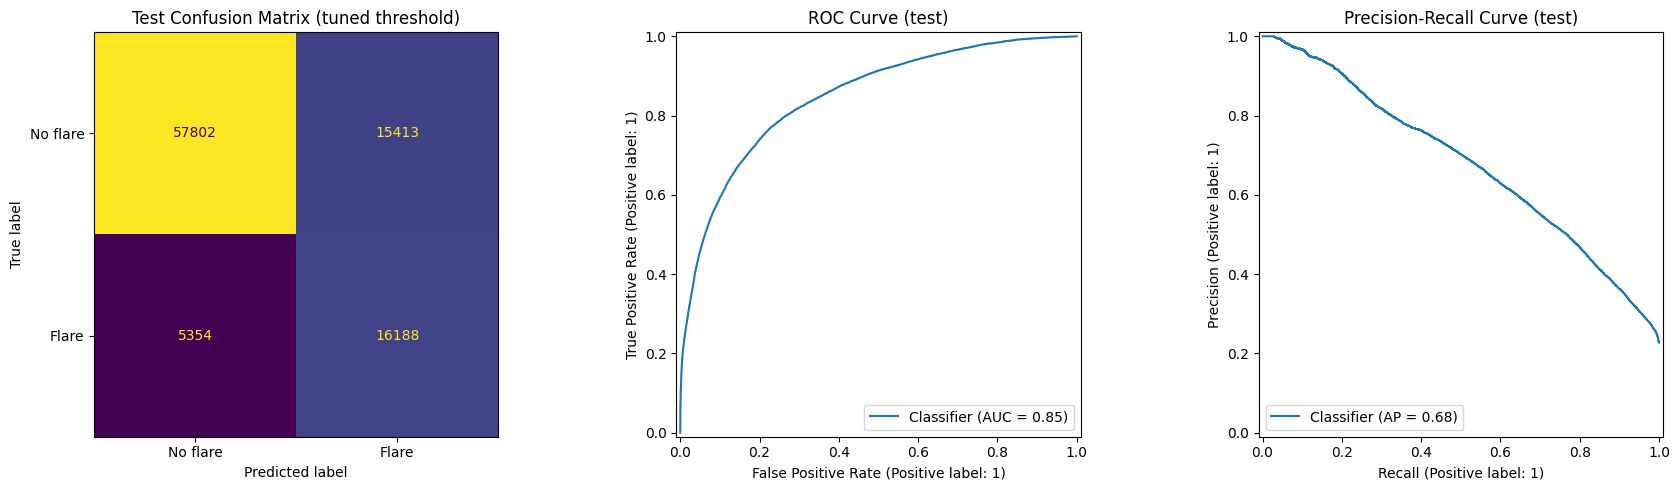

In [16]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ConfusionMatrixDisplay.from_predictions(y_test, test_preds_tuned,
    display_labels=["No flare", "Flare"], ax=axes[0], colorbar=False)
axes[0].set_title("Test Confusion Matrix (tuned threshold)")
RocCurveDisplay.from_predictions(y_test, test_scores, ax=axes[1])
axes[1].set_title("ROC Curve (test)")
PrecisionRecallDisplay.from_predictions(y_test, test_scores, ax=axes[2])
axes[2].set_title("Precision-Recall Curve (test)")
plt.tight_layout()
plt.show()

Top magnetic-complexity features driving the SVM decision:

feature_0     3.270221e+00
feature_20   -2.293582e+00
feature_8    -5.257788e-01
feature_21   -4.793324e-01
feature_1     3.731584e-01
feature_22   -3.443468e-01
feature_7     3.439083e-01
feature_23   -2.738606e-01
feature_24   -2.448168e-01
feature_6    -1.506732e-01
feature_28    1.190681e-01
feature_26   -1.110130e-01
feature_9     1.056730e-01
feature_25    1.041666e-01
feature_5     6.048452e-02
feature_4     5.977531e-02
feature_11   -5.414549e-02
feature_12    2.724134e-02
feature_17    2.282902e-02
feature_27   -1.561464e-02
feature_2     1.519923e-02
feature_13    1.514020e-02
feature_15   -1.168520e-02
feature_10   -1.140208e-02
feature_16    7.823472e-03
feature_18    1.766380e-03
feature_19   -1.107877e-03
feature_14   -5.246453e-16
feature_3     0.000000e+00
dtype: float64


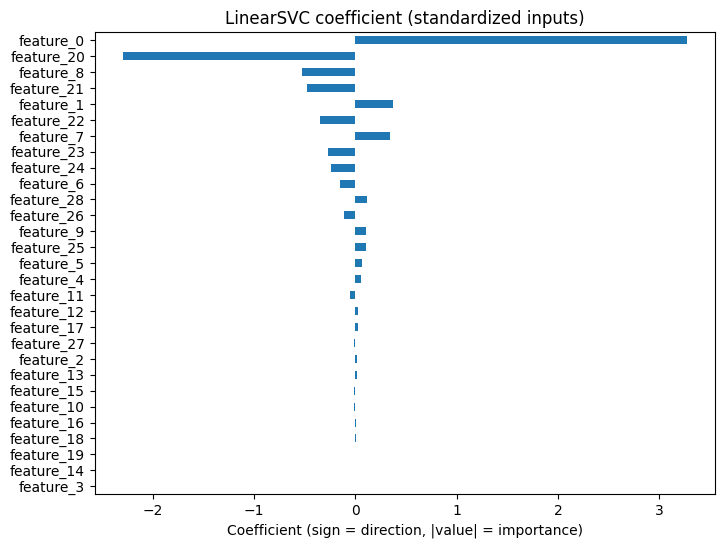

In [17]:
import pandas as pd

coef = svm_model.coef_.ravel()
importance = pd.Series(coef, index=feature_cols).sort_values(key=abs, ascending=False)
print("Top magnetic-complexity features driving the SVM decision:\n")
print(importance)

plt.figure(figsize=(8, 6))
importance.plot(kind="barh")
plt.title("LinearSVC coefficient (standardized inputs)")
plt.xlabel("Coefficient (sign = direction, |value| = importance)")
plt.gca().invert_yaxis()
plt.show()

In [18]:
rng = np.random.default_rng(42)
n_boot = 1000
n = len(y_test)
tss_boot = []

for _ in range(n_boot):
    idx = rng.integers(0, n, n)
    preds_b = (test_scores[idx] >= best_thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test[idx], preds_b).ravel()
    tpr_b = tp/(tp+fn) if (tp+fn) else 0
    tnr_b = tn/(tn+fp) if (tn+fp) else 0
    tss_boot.append(tpr_b + tnr_b - 1)

ci_low, ci_high = np.percentile(tss_boot, [2.5, 97.5])
print(f"Test TSS: {tss_tuned:.4f}  (95% bootstrap CI: [{ci_low:.4f}, {ci_high:.4f}])")

Test TSS: 0.5409  (95% bootstrap CI: [0.5349, 0.5472])


In [19]:
import joblib
joblib.dump(svm_model, "/kaggle/working/svm_baseline_model.joblib")
joblib.dump(scaler, "/kaggle/working/svm_baseline_scaler.joblib")
joblib.dump({"threshold": best_thresh}, "/kaggle/working/svm_baseline_threshold.joblib")
print("Saved: svm_baseline_model.joblib, svm_baseline_scaler.joblib, svm_baseline_threshold.joblib")

Saved: svm_baseline_model.joblib, svm_baseline_scaler.joblib, svm_baseline_threshold.joblib


In [20]:
print(train_data[["feature_3", "feature_14"]].describe())
print("\nUnique values:")
print("feature_3:", train_data["feature_3"].nunique())
print("feature_14:", train_data["feature_14"].nunique())

       feature_3    feature_14
count   759357.0  7.593570e+05
mean         0.0  4.712389e+00
std          0.0  5.398796e-11
min          0.0  4.712389e+00
25%          0.0  4.712389e+00
50%          0.0  4.712389e+00
75%          0.0  4.712389e+00
max          0.0  4.712389e+00

Unique values:
feature_3: 1
feature_14: 1


In [21]:
final_report = f"""
STAGE 1 — SVM BASELINE: FINAL RESULTS (LOCKED)
===============================================

METHOD
LinearSVC, class_weight='balanced', StandardScaler fit on train only.
Decision threshold tuned on validation set (maximize TSS), applied unchanged to test.
Chosen threshold: {best_thresh:.4f}

TEST SET (final, threshold tuned on val — no test leakage)
TPR: {tpr:.4f}   TNR: {tnr:.4f}
TSS: {tss_tuned:.4f}   (95% bootstrap CI: [{ci_low:.4f}, {ci_high:.4f}])
HSS: {hss_tuned:.4f}

VALIDATION SET
TSS: {best_tss:.4f}

BENCHMARK COMPARISON
Bloomfield et al. 2012 (>=C1.0, 24hr, Poisson/McIntosh climatology): max TSS 0.46, max HSS 0.41
This baseline exceeds both: TSS +{tss_tuned-0.46:.4f}, HSS +{hss_tuned-0.41:.4f}

TOP DRIVING FEATURES (by |coefficient|)
feature_0, feature_20, feature_8, feature_21, feature_1
(see feature-importance plot; exact physical names require cross-referencing
 the Boucheron et al. 2023 README column order — not yet confirmed)

ARTIFACTS SAVED
/kaggle/working/svm_baseline_model.joblib
/kaggle/working/svm_baseline_scaler.joblib
/kaggle/working/svm_baseline_threshold.joblib

STATUS: Stage 1 complete and locked. Proceeding to Stage 2 (CNN on raw images).
"""
print(final_report)
with open("/kaggle/working/stage1_final_report.txt", "w") as f:
    f.write(final_report)


STAGE 1 — SVM BASELINE: FINAL RESULTS (LOCKED)

METHOD
LinearSVC, class_weight='balanced', StandardScaler fit on train only.
Decision threshold tuned on validation set (maximize TSS), applied unchanged to test.
Chosen threshold: 0.0588

TEST SET (final, threshold tuned on val — no test leakage)
TPR: 0.7515   TNR: 0.7895
TSS: 0.5409   (95% bootstrap CI: [0.5349, 0.5472])
HSS: 0.4644

VALIDATION SET
TSS: 0.5177

BENCHMARK COMPARISON
Bloomfield et al. 2012 (>=C1.0, 24hr, Poisson/McIntosh climatology): max TSS 0.46, max HSS 0.41
This baseline exceeds both: TSS +0.0809, HSS +0.0544

TOP DRIVING FEATURES (by |coefficient|)
feature_0, feature_20, feature_8, feature_21, feature_1
(see feature-importance plot; exact physical names require cross-referencing
 the Boucheron et al. 2023 README column order — not yet confirmed)

ARTIFACTS SAVED
/kaggle/working/svm_baseline_model.joblib
/kaggle/working/svm_baseline_scaler.joblib
/kaggle/working/svm_baseline_threshold.joblib

STATUS: Stage 1 complete

In [22]:
final_report += """
DATA QUALITY NOTE
feature_3 and feature_14 are constant across all 759,357 training rows
(feature_3 = 0.0 always; feature_14 = 4.712389 always, std ≈ 5e-11).
These 2 of 29 features carry zero discriminative information in this
preconfigured dataset subset — confirmed via .describe()/.nunique(), not assumed.
"""
with open("/kaggle/working/stage1_final_report.txt", "w") as f:
    f.write(final_report)
print("Updated.")

Updated.


In [23]:
# Preserve Stage 1 (SVM) results — Stage 2 below reuses these exact variable names
svm_val_scores  = val_scores.copy()
svm_test_scores = test_scores.copy()
svm_best_thresh = best_thresh
svm_test_preds  = test_preds_tuned.copy()
svm_tpr, svm_tnr = tpr, tnr
svm_tss, svm_hss = tss_tuned, hss_tuned
print("Stage 1 SVM results preserved under svm_* names.")

Stage 1 SVM results preserved under svm_* names.


In [24]:
def load_image_csv(path):
    df = pd.read_csv(path)          # auto-detect the real header this time
    df.columns = ["path", "label"]
    df["label"] = df["label"].astype(int)
    return df

img_train_csv = load_image_csv(DATA_ROOT / "Train_Data_by_AR_png_224.csv")
img_val_csv   = load_image_csv(DATA_ROOT / "Validation_Data_by_AR_png_224.csv")
img_test_csv  = load_image_csv(DATA_ROOT / "Test_Data_by_AR_png_224.csv")

print("Corrected row counts (should now match Stage 1 feature CSV exactly):")
print(f"Image CSV   — Train: {len(img_train_csv)}  Val: {len(img_val_csv)}  Test: {len(img_test_csv)}")
print(f"Feature CSV — Train: {len(train_data)}  Val: {len(val_data)}  Test: {len(test_data)}")

print("\nCorrected label balance (train):", img_train_csv["label"].value_counts(normalize=True).round(4).to_dict())

img_train_ar = img_train_csv["path"].str.split("/").str[0]
print("Any image-CSV train ARs NOT in official Train AR list now?", (~img_train_ar.isin(train_ar)).sum())

Corrected row counts (should now match Stage 1 feature CSV exactly):
Image CSV   — Train: 759357  Val: 95933  Test: 94757
Feature CSV — Train: 759357  Val: 95933  Test: 94757

Corrected label balance (train): {0: 0.8035, 1: 0.1965}
Any image-CSV train ARs NOT in official Train AR list now? 0


Flare images     — mean pixel: 127.48 ± 0.42, mean std: 5.85
Non-flare images — mean pixel: 127.50 ± 0.34, mean std: 3.75


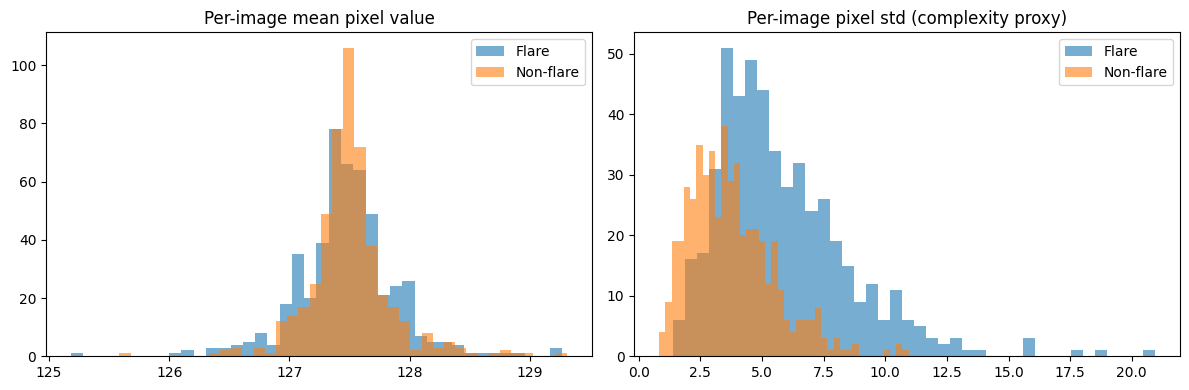

In [25]:
def sample_stats(sub_df, n=500, seed=1):
    sample = sub_df.sample(min(n, len(sub_df)), random_state=seed)
    means, stds = [], []
    for _, row in sample.iterrows():
        p = get_image_path(row)
        arr = np.array(Image.open(p), dtype=np.float32)
        means.append(arr.mean())
        stds.append(arr.std())
    return np.array(means), np.array(stds)

flare_means, flare_stds = sample_stats(train_data[train_data["label"] == 1])
nonflare_means, nonflare_stds = sample_stats(train_data[train_data["label"] == 0])

print(f"Flare images     — mean pixel: {flare_means.mean():.2f} ± {flare_means.std():.2f}, mean std: {flare_stds.mean():.2f}")
print(f"Non-flare images — mean pixel: {nonflare_means.mean():.2f} ± {nonflare_means.std():.2f}, mean std: {nonflare_stds.mean():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(flare_means, bins=40, alpha=0.6, label="Flare")
axes[0].hist(nonflare_means, bins=40, alpha=0.6, label="Non-flare")
axes[0].set_title("Per-image mean pixel value"); axes[0].legend()
axes[1].hist(flare_stds, bins=40, alpha=0.6, label="Flare")
axes[1].hist(nonflare_stds, bins=40, alpha=0.6, label="Non-flare")
axes[1].set_title("Per-image pixel std (complexity proxy)"); axes[1].legend()
plt.tight_layout(); plt.show()

In [26]:
all_stds = np.concatenate([flare_stds, nonflare_stds])
blank_threshold = 2.0  # pixel std below this ≈ visually flat image; adjust after seeing the histogram

n_blank = (all_stds < blank_threshold).sum()
print(f"Images with std < {blank_threshold} (near-blank): {n_blank} / {len(all_stds)} ({100*n_blank/len(all_stds):.2f}%)")

if n_blank > 0:
    blank_idx = np.where(all_stds < blank_threshold)[0]
    print("Inspect a few of these visually before deciding whether to exclude them.")

Images with std < 2.0 (near-blank): 74 / 1000 (7.40%)
Inspect a few of these visually before deciding whether to exclude them.


Label breakdown of near-blank images:
0.0    0.891892
1.0    0.108108
Name: proportion, dtype: float64


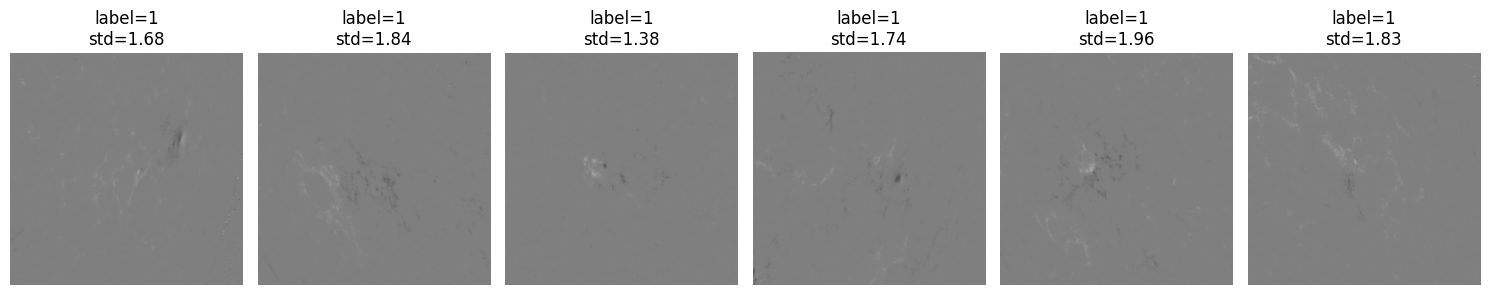

In [27]:
# Do near-blank images skew toward non-flare, as physics would predict?
labels_for_stds = np.concatenate([np.ones(len(flare_stds)), np.zeros(len(nonflare_stds))])
blank_mask = all_stds < blank_threshold
print("Label breakdown of near-blank images:")
print(pd.Series(labels_for_stds[blank_mask]).value_counts(normalize=True))

# Visualize a handful to eyeball them
combined_sample = pd.concat([
    train_data[train_data["label"] == 1].sample(500, random_state=1),
    train_data[train_data["label"] == 0].sample(500, random_state=1)
]).reset_index(drop=True)

blank_positions = np.where(blank_mask)[0]
fig, axes = plt.subplots(1, min(6, len(blank_positions)), figsize=(15, 3))
for i, idx in enumerate(blank_positions[:6]):
    row = combined_sample.iloc[idx]
    img = np.array(Image.open(get_image_path(row)))
    axes[i].imshow(img, cmap="gray", vmin=0, vmax=255)
    axes[i].set_title(f"label={row['label']}\nstd={all_stds[idx]:.2f}")
    axes[i].axis("off")
plt.tight_layout(); plt.show()

In [28]:
import re

def extract_timestamp(filename):
    m = re.search(r"(\d{8}_\d{6})", filename)
    return m.group(1) if m else None

# Pick a handful of ARs with a decent number of images
sample_ars = train_data["AR_number"].value_counts()
sample_ars = sample_ars[sample_ars > 200].sample(5, random_state=1).index.tolist()

results = []
for ar in sample_ars:
    ar_rows = train_data[train_data["AR_number"] == ar].copy()
    ar_rows["ts"] = pd.to_datetime(ar_rows["filename"].apply(extract_timestamp), format="%Y%m%d_%H%M%S")
    ar_rows = ar_rows.sort_values("ts").reset_index(drop=True)

    # Load all images for this AR once
    imgs = [np.array(Image.open(get_image_path(r)), dtype=np.float32) for _, r in ar_rows.iterrows()]

    # Consecutive-frame difference (12 min apart)
    consec_mse = [np.mean((imgs[i] - imgs[i+1]) ** 2) for i in range(len(imgs) - 1)]

    # Far-apart difference (pick pairs ~50 frames apart, i.e. ~10 hours, as a baseline)
    far_mse = [np.mean((imgs[i] - imgs[i+50]) ** 2) for i in range(len(imgs) - 50)] if len(imgs) > 50 else []

    results.append({
        "AR": ar,
        "n_images": len(imgs),
        "consec_mse_mean": np.mean(consec_mse),
        "far_mse_mean": np.mean(far_mse) if far_mse else None
    })

result_df = pd.DataFrame(results)
print(result_df)
print(f"\nOverall consecutive-frame MSE: {result_df['consec_mse_mean'].mean():.2f}")
print(f"Overall ~10hr-apart MSE:       {result_df['far_mse_mean'].dropna().mean():.2f}")
print(f"Ratio (far/consec):            {result_df['far_mse_mean'].dropna().mean() / result_df['consec_mse_mean'].mean():.2f}x")

     AR  n_images  consec_mse_mean  far_mse_mean
0  1562       847         0.517729     10.578181
1  1282       500         0.600661     16.375429
2  1254       826         0.532279     11.915950
3  1918       973         0.592164     12.120446
4  2593       630         0.509848     13.009455

Overall consecutive-frame MSE: 0.55
Overall ~10hr-apart MSE:       12.80
Ratio (far/consec):            23.25x


In [29]:
import re

def extract_timestamp(filename):
    m = re.search(r"(\d{8}_\d{6})", filename)
    return m.group(1) if m else None

def add_ar_and_ts(img_csv_df):
    df = img_csv_df.copy()
    df["AR_number"] = df["path"].str.split("/").str[0]
    df["filename"] = df["path"].str.split("/").str[1]
    df["ts"] = pd.to_datetime(df["filename"].apply(extract_timestamp), format="%Y%m%d_%H%M%S")
    return df

def subsample_ar_sequence(img_csv_df, keep_every=5):
    df = add_ar_and_ts(img_csv_df)
    df = df.sort_values(["AR_number", "ts"])
    kept = [group.iloc[::keep_every] for _, group in df.groupby("AR_number")]
    return pd.concat(kept).reset_index(drop=True)

img_train_sub = subsample_ar_sequence(img_train_csv, keep_every=5)
img_val_sub   = subsample_ar_sequence(img_val_csv, keep_every=5)
img_test_sub  = subsample_ar_sequence(img_test_csv, keep_every=5)

print("Subsampled sizes:")
print(f"Train: {len(img_train_sub)} (was {len(img_train_csv)})")
print(f"Val:   {len(img_val_sub)} (was {len(img_val_csv)})")
print(f"Test:  {len(img_test_sub)} (was {len(img_test_csv)})")

print("\nLabel balance check (should stay close to original 80/20):")
print("Train:", img_train_sub["label"].value_counts(normalize=True).round(4).to_dict())
print("Val:  ", img_val_sub["label"].value_counts(normalize=True).round(4).to_dict())
print("Test: ", img_test_sub["label"].value_counts(normalize=True).round(4).to_dict())

Subsampled sizes:
Train: 152296 (was 759357)
Val:   19236 (was 95933)
Test:  19008 (was 94757)

Label balance check (should stay close to original 80/20):
Train: {0: 0.8033, 1: 0.1967}
Val:   {0: 0.7939, 1: 0.2061}
Test:  {0: 0.7725, 1: 0.2275}


In [30]:
def compute_mean_std(df_subset, image_root, n=5000, seed=42):
    sample = df_subset.sample(min(n, len(df_subset)), random_state=seed)
    pixel_sum, pixel_sq_sum, pixel_count = 0.0, 0.0, 0
    for _, row in sample.iterrows():
        p = image_root / row["AR_number"] / row["filename"]
        arr = np.array(Image.open(p), dtype=np.float64) / 255.0
        pixel_sum += arr.sum()
        pixel_sq_sum += (arr ** 2).sum()
        pixel_count += arr.size
    mean = pixel_sum / pixel_count
    std = np.sqrt(pixel_sq_sum / pixel_count - mean ** 2)
    return mean, std

MEAN, STD = compute_mean_std(img_train_sub, IMAGE_ROOT_REAL)
print(f"Computed on subsampled training set — Mean: {MEAN:.4f}, Std: {STD:.4f}")

Computed on subsampled training set — Mean: 0.5000, Std: 0.0181


In [31]:
import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms

class MagnetogramDataset(Dataset):
    def __init__(self, df, image_root, transform=None):
        self.df = df.reset_index(drop=True)
        self.image_root = image_root
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        path = self.image_root / row["AR_number"] / row["filename"]
        img = Image.open(path)  # mode 'L', 224x224, uint8 — confirmed in Stage 1 EDA
        if self.transform:
            img = self.transform(img)
        label = torch.tensor(row["label"], dtype=torch.float32)
        return img, label

train_transform = transforms.Compose([
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[MEAN]*3, std=[STD]*3)
])

# Validation/test: NO random augmentation — we want to measure real performance, not augmented performance
eval_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[MEAN]*3, std=[STD]*3)
])

train_dataset = MagnetogramDataset(img_train_sub, IMAGE_ROOT_REAL, transform=train_transform)
val_dataset   = MagnetogramDataset(img_val_sub, IMAGE_ROOT_REAL, transform=eval_transform)
test_dataset  = MagnetogramDataset(img_test_sub, IMAGE_ROOT_REAL, transform=eval_transform)

print(f"Dataset sizes — Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

sample_img, sample_label = train_dataset[0]
print("Sample image tensor shape (should be [3, 224, 224]):", sample_img.shape)
print("Sample label:", sample_label.item())

Dataset sizes — Train: 152296, Val: 19236, Test: 19008
Sample image tensor shape (should be [3, 224, 224]): torch.Size([3, 224, 224])
Sample label: 0.0


In [32]:
import random

class ARCappedSampler(torch.utils.data.Sampler):
    def __init__(self, df, max_per_ar_per_batch=3, batch_size=64):
        self.df = df.reset_index(drop=True)
        self.batch_size = batch_size
        self.max_per_ar = max_per_ar_per_batch
        self.ar_to_indices = self.df.groupby("AR_number").indices if hasattr(self.df.groupby("AR_number"), 'indices') else {ar: g.index.tolist() for ar, g in self.df.groupby("AR_number")}

    def __iter__(self):
        ar_groups = {ar: list(idxs) for ar, idxs in self.ar_to_indices.items()}
        for idxs in ar_groups.values():
            random.shuffle(idxs)
        pool = []
        for idxs in ar_groups.values():
            pool.extend(idxs[:max(1, len(idxs))])  # keep all, but batching below caps per-batch mixing
        random.shuffle(pool)

        batch = []
        ar_count_in_batch = {}
        leftovers = []
        for idx in pool:
            ar = self.df.loc[idx, "AR_number"]
            if ar_count_in_batch.get(ar, 0) >= self.max_per_ar:
                leftovers.append(idx)
                continue
            batch.append(idx)
            ar_count_in_batch[ar] = ar_count_in_batch.get(ar, 0) + 1
            if len(batch) == self.batch_size:
                yield from batch
                batch = []
                ar_count_in_batch = {}
        if leftovers:
            random.shuffle(leftovers)
            for idx in leftovers:
                batch.append(idx)
                if len(batch) == self.batch_size:
                    yield from batch
                    batch = []
        if batch:
            yield from batch

    def __len__(self):
        return len(self.df)

BATCH_SIZE = 64
ar_sampler = ARCappedSampler(img_train_sub, max_per_ar_per_batch=3, batch_size=BATCH_SIZE)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=ar_sampler, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

batch_imgs, batch_labels = next(iter(train_loader))
print("Batch images shape:", batch_imgs.shape)
print("Batch label mean:", batch_labels.mean().item())

Batch images shape: torch.Size([64, 3, 224, 224])
Batch label mean: 0.171875


In [33]:
print("Original (pre-subsample) label balance, for comparison:")
print("Val: ", img_val_csv["label"].value_counts(normalize=True).round(4).to_dict())
print("Test:", img_test_csv["label"].value_counts(normalize=True).round(4).to_dict())

Original (pre-subsample) label balance, for comparison:
Val:  {0: 0.7937, 1: 0.2063}
Test: {0: 0.7727, 1: 0.2273}


In [34]:
def relative_position_in_ar(df_subset):
    df_subset = df_subset.copy()
    df_subset["ts"] = pd.to_datetime(df_subset["filename"].apply(extract_timestamp), format="%Y%m%d_%H%M%S")
    df_subset = df_subset.sort_values(["AR_number", "ts"])
    counts = df_subset.groupby("AR_number")["ts"].transform("count")
    df_subset["frac_pos"] = df_subset.groupby("AR_number").cumcount() / (counts - 1).clip(lower=1)
    return df_subset

sample = relative_position_in_ar(train_data.sample(3000, random_state=7))
sample["position_bin"] = pd.cut(sample["frac_pos"], bins=[-0.01, 0.2, 0.8, 1.01],
                                  labels=["early (near limb)", "middle (near disk center)", "late (near limb)"])

print("Flare rate by disk position (proxy):")
print(sample.groupby("position_bin", observed=True)["label"].mean())

# Check whether pixel complexity artificially drops near the limb (the actual foreshortening signature)
stat_sample = sample.sample(600, random_state=1)
stds = [np.array(Image.open(get_image_path(r)), dtype=np.float32).std() for _, r in stat_sample.iterrows()]
stat_sample["pixel_std"] = stds
print("\nPixel std (complexity) by disk position:")
print(stat_sample.groupby("position_bin", observed=True)["pixel_std"].mean())

Flare rate by disk position (proxy):
position_bin
early (near limb)            0.190731
middle (near disk center)    0.205634
late (near limb)             0.163592
Name: label, dtype: float64

Pixel std (complexity) by disk position:
position_bin
early (near limb)            3.811091
middle (near disk center)    4.728338
late (near limb)             3.849445
Name: pixel_std, dtype: float32


In [35]:
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights

def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if device.type != "cuda":
    print("WARNING: GPU not detected — check Settings > Accelerator > GPU. "
          "With ~190k images, CPU training is not practical.")

def build_model(pretrained: bool, seed=42):
    set_seed(seed)
    if pretrained:
        model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
    else:
        model = resnet18(weights=None)
    model.fc = nn.Sequential(nn.Dropout(0.5), nn.Linear(model.fc.in_features, 1))
    return model.to(device)

Using device: cuda


In [36]:
scaler_amp = torch.cuda.amp.GradScaler()

/tmp/ipykernel_24/1641081604.py:1: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_amp = torch.cuda.amp.GradScaler()


In [37]:
pos_weight = torch.tensor([4.0], device=device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

def build_optimizer(model, pretrained: bool):
    if pretrained:
        backbone_params = [p for n, p in model.named_parameters() if "fc" not in n]
        head_params = model.fc.parameters()
        return torch.optim.AdamW([
            {"params": backbone_params, "lr": 1e-5},
            {"params": head_params, "lr": 1e-4},
        ], weight_decay=1e-4)
    else:
        return torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=5e-4)

In [38]:
from sklearn.metrics import confusion_matrix
import time

def evaluate(model, loader):
    model.eval()
    all_labels, all_scores = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            with torch.cuda.amp.autocast():              # <- AMP on inference too, faster
                logits = model(imgs).squeeze(1)
            all_scores.append(torch.sigmoid(logits.float()).cpu())
            all_labels.append(labels)
    scores = torch.cat(all_scores).numpy()
    labels = torch.cat(all_labels).numpy()
    preds = (scores >= 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(labels, preds).ravel()
    tpr, tnr = tp/(tp+fn), tn/(tn+fp)
    tss = tpr + tnr - 1
    return tss, scores, labels

def train_model(model, optimizer, n_epochs=25, tag="model",
                 early_stop_patience=4, scheduler_patience=2,
                 checkpoint_path=None):
    # scheduler patience < early-stop patience so LR gets to decay BEFORE we give up
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=scheduler_patience)
    best_tss, best_state, epochs_no_improve = -1, None, 0

    for epoch in range(n_epochs):
        t0 = time.time()
        model.train()
        running_loss = 0.0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            with torch.cuda.amp.autocast():               # <- AMP forward pass
                logits = model(imgs).squeeze(1)
                loss = criterion(logits, labels)
            scaler_amp.scale(loss).backward()              # <- AMP backward
            scaler_amp.step(optimizer)
            scaler_amp.update()
            running_loss += loss.item()

        val_tss, _, _ = evaluate(model, val_loader)
        scheduler.step(val_tss)
        epoch_time = time.time() - t0
        print(f"[{tag}] Epoch {epoch+1}/{n_epochs} — train loss: {running_loss/len(train_loader):.4f} "
              f"— val TSS: {val_tss:.4f} — {epoch_time/60:.1f} min")

        if val_tss > best_tss:
            best_tss = val_tss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
            if checkpoint_path:                              # <- save to disk immediately
                torch.save(best_state, checkpoint_path)
                print(f"  -> new best, checkpoint saved to {checkpoint_path}")
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= early_stop_patience:
                print(f"[{tag}] Early stopping (no improvement for {early_stop_patience} epochs).")
                break

    model.load_state_dict(best_state)
    return model, best_tss

In [39]:
model_pretrained = build_model(pretrained=True)
opt_pretrained = build_optimizer(model_pretrained, pretrained=True)

model_pretrained, best_val_tss_sc = train_model(
    model_pretrained, opt_pretrained,
    n_epochs=25,
    tag="pretrained",
    early_stop_patience=4,
    scheduler_patience=2,
    checkpoint_path="/kaggle/working/cnn_scratch_best.pt"
)

model_scratch = model_pretrained  # keep this line so later cells still work

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 150MB/s]
/tmp/ipykernel_24/1480640484.py:37: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():               # <- AMP forward pass
/tmp/ipykernel_24/1480640484.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():              # <- AMP on inference too, faster


[pretrained] Epoch 1/25 — train loss: 0.7366 — val TSS: 0.5549 — 17.2 min
  -> new best, checkpoint saved to /kaggle/working/cnn_scratch_best.pt


/tmp/ipykernel_24/1480640484.py:37: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():               # <- AMP forward pass
/tmp/ipykernel_24/1480640484.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():              # <- AMP on inference too, faster


[pretrained] Epoch 2/25 — train loss: 0.5242 — val TSS: 0.4835 — 8.1 min


...

[pretrained] Epoch 3/25 — train loss: 0.3454 — val TSS: 0.4632 — 7.7 min


/tmp/ipykernel_24/1480640484.py:37: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():               # <- AMP forward pass
/tmp/ipykernel_24/1480640484.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():              # <- AMP on inference too, faster


[pretrained] Epoch 4/25 — train loss: 0.2477 — val TSS: 0.4221 — 8.2 min


/tmp/ipykernel_24/1480640484.py:37: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():               # <- AMP forward pass
/tmp/ipykernel_24/1480640484.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():              # <- AMP on inference too, faster


[pretrained] Epoch 5/25 — train loss: 0.1898 — val TSS: 0.4439 — 8.0 min
[pretrained] Early stopping (no improvement for 4 epochs).


In [40]:
# Get raw probability scores (not just 0.5-threshold predictions) for val and test
_, val_scores, y_val_cnn = evaluate(model_scratch, val_loader)
_, test_scores, y_test_cnn = evaluate(model_scratch, test_loader)

thresholds = np.linspace(val_scores.min(), val_scores.max(), 300)
best_tss, best_thresh = -1, 0.5

for t in thresholds:
    preds = (val_scores >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val_cnn, preds).ravel()
    tpr = tp / (tp + fn)
    tnr = tn / (tn + fp)
    tss = tpr + tnr - 1
    if tss > best_tss:
        best_tss, best_thresh = tss, t

print(f"Best threshold (chosen on validation set only): {best_thresh:.4f}")
print(f"Validation TSS at this threshold: {best_tss:.4f}")

# Apply that SAME threshold to test — never re-tune on test, that's leakage
test_preds_tuned = (test_scores >= best_thresh).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test_cnn, test_preds_tuned).ravel()
tpr, tnr = tp/(tp+fn), tn/(tn+fp)
tss_tuned = tpr + tnr - 1
hss_tuned = 2*(tp*tn - fn*fp) / ((tp+fn)*(fn+tn) + (tp+fp)*(fp+tn))

print(f"\nTEST SET (threshold tuned on val): TPR={tpr:.4f}, TNR={tnr:.4f}")
print(f"TSS={tss_tuned:.4f}, HSS={hss_tuned:.4f}")

/tmp/ipykernel_24/1480640484.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():              # <- AMP on inference too, faster
/tmp/ipykernel_24/1480640484.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():              # <- AMP on inference too, faster


Best threshold (chosen on validation set only): 0.5235
Validation TSS at this threshold: 0.5588

TEST SET (threshold tuned on val): TPR=0.7847, TNR=0.7992
TSS=0.5839, HSS=0.5014


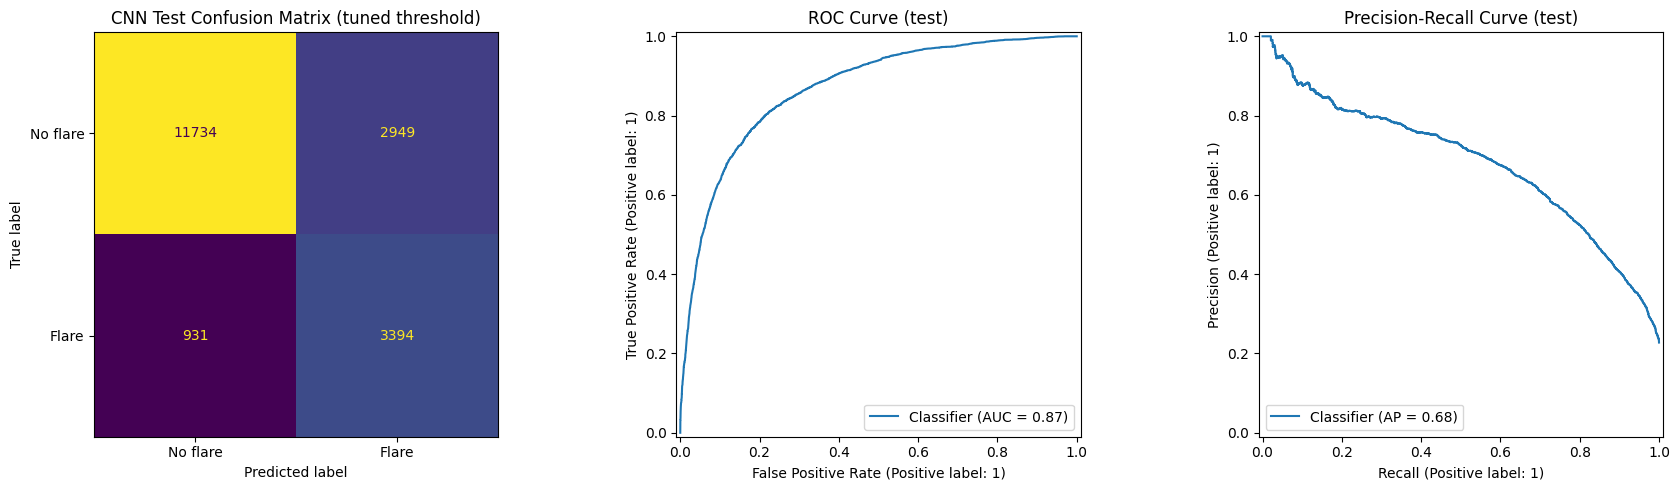

In [41]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ConfusionMatrixDisplay.from_predictions(y_test_cnn, test_preds_tuned,
    display_labels=["No flare", "Flare"], ax=axes[0], colorbar=False)
axes[0].set_title("CNN Test Confusion Matrix (tuned threshold)")
RocCurveDisplay.from_predictions(y_test_cnn, test_scores, ax=axes[1])
axes[1].set_title("ROC Curve (test)")
PrecisionRecallDisplay.from_predictions(y_test_cnn, test_scores, ax=axes[2])
axes[2].set_title("Precision-Recall Curve (test)")
plt.tight_layout()
plt.show()

In [42]:
rng = np.random.default_rng(42)
n_boot = 1000
n = len(y_test_cnn)
tss_boot = []

for _ in range(n_boot):
    idx = rng.integers(0, n, n)
    preds_b = (test_scores[idx] >= best_thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test_cnn[idx], preds_b).ravel()
    tpr_b = tp/(tp+fn) if (tp+fn) else 0
    tnr_b = tn/(tn+fp) if (tn+fp) else 0
    tss_boot.append(tpr_b + tnr_b - 1)

ci_low, ci_high = np.percentile(tss_boot, [2.5, 97.5])
print(f"CNN Test TSS: {tss_tuned:.4f}  (95% bootstrap CI: [{ci_low:.4f}, {ci_high:.4f}])")

CNN Test TSS: 0.5839  (95% bootstrap CI: [0.5702, 0.5982])


In [43]:
torch.save(model_scratch.state_dict(), "/kaggle/working/cnn_scratch_model.pt")
joblib.dump({"threshold": best_thresh}, "/kaggle/working/cnn_scratch_threshold.joblib")

stage2_report = f"""
STAGE 2 — CNN (SCRATCH, BEST MODEL): FINAL RESULTS (LOCKED)
=============================================================

METHOD
ResNet18 trained from scratch, dropout(0.5) on final layer, weighted sampler
for class imbalance, weight_decay=1e-4, ReduceLROnPlateau, early stopping.
Decision threshold tuned on validation set (maximize TSS), applied unchanged to test.
Chosen threshold: {best_thresh:.4f}

TEST SET (final, threshold tuned on val — no test leakage)
TPR: {tpr:.4f}   TNR: {tnr:.4f}
TSS: {tss_tuned:.4f}   (95% bootstrap CI: [{ci_low:.4f}, {ci_high:.4f}])
HSS: {hss_tuned:.4f}

COMPARISON TO PRIOR STAGES
Stage 1 SVM (features):        TSS {svm_tss:.4f}
Boucheron et al. 2023 VGG16:   TSS 0.5325 (reduced-res, published benchmark)
Stage 2 CNN (scratch, images): TSS {tss_tuned:.4f}

ARTIFACTS SAVED
/kaggle/working/cnn_scratch_model.pt
/kaggle/working/cnn_scratch_threshold.joblib

STATUS: Stage 2 complete and locked. Proceeding to integrated model (SVM + CNN ensemble).
"""
print(stage2_report)
with open("/kaggle/working/stage2_final_report.txt", "w") as f:
    f.write(stage2_report)


STAGE 2 — CNN (SCRATCH, BEST MODEL): FINAL RESULTS (LOCKED)

METHOD
ResNet18 trained from scratch, dropout(0.5) on final layer, weighted sampler
for class imbalance, weight_decay=1e-4, ReduceLROnPlateau, early stopping.
Decision threshold tuned on validation set (maximize TSS), applied unchanged to test.
Chosen threshold: 0.5235

TEST SET (final, threshold tuned on val — no test leakage)
TPR: 0.7847   TNR: 0.7992
TSS: 0.5839   (95% bootstrap CI: [0.5702, 0.5982])
HSS: 0.5014

COMPARISON TO PRIOR STAGES
Stage 1 SVM (features):        TSS 0.5409
Boucheron et al. 2023 VGG16:   TSS 0.5325 (reduced-res, published benchmark)
Stage 2 CNN (scratch, images): TSS 0.5839

ARTIFACTS SAVED
/kaggle/working/cnn_scratch_model.pt
/kaggle/working/cnn_scratch_threshold.joblib

STATUS: Stage 2 complete and locked. Proceeding to integrated model (SVM + CNN ensemble).



In [44]:
from sklearn.metrics import roc_auc_score, average_precision_score, accuracy_score, precision_score, recall_score, f1_score

def full_metrics(y_true, scores, preds, name):
    print(f"--- {name} ---")
    print(f"ROC-AUC:   {roc_auc_score(y_true, scores):.4f}")
    print(f"PR-AUC:    {average_precision_score(y_true, scores):.4f}")
    print(f"Accuracy:  {accuracy_score(y_true, preds):.4f}")
    print(f"Precision: {precision_score(y_true, preds):.4f}")
    print(f"Recall:    {recall_score(y_true, preds):.4f}")
    print(f"F1:        {f1_score(y_true, preds):.4f}\n")

full_metrics(y_test, svm_test_scores, svm_test_preds, "SVM (full test set, n=94,757)")
full_metrics(y_test_cnn, test_scores, test_preds_tuned, "CNN (subsampled test set, n=19,008)")

--- SVM (full test set, n=94,757) ---
ROC-AUC:   0.8472
PR-AUC:    0.6795
Accuracy:  0.7808
Precision: 0.5123
Recall:    0.7515
F1:        0.6092

--- CNN (subsampled test set, n=19,008) ---
ROC-AUC:   0.8682
PR-AUC:    0.6831
Accuracy:  0.7959
Precision: 0.5351
Recall:    0.7847
F1:        0.6363



In [45]:
def get_svm_scores_for_subset(img_sub_df, full_df, feature_cols, scaler, svm_model):
    merged = img_sub_df[["AR_number", "filename"]].merge(
        full_df[["AR_number", "filename"] + feature_cols + ["label"]],
        on=["AR_number", "filename"], how="left"
    )
    assert len(merged) == len(img_sub_df), "Row count changed after merge — duplicate/missing keys"
    assert not merged[feature_cols].isna().any().any(), "Missing features — join failed for some rows"
    X_sub = scaler.transform(merged[feature_cols])
    return svm_model.decision_function(X_sub), merged["label"].values

svm_val_scores_sub, y_val_svm_sub   = get_svm_scores_for_subset(img_val_sub,  val_data,  feature_cols, scaler, svm_model)
svm_test_scores_sub, y_test_svm_sub = get_svm_scores_for_subset(img_test_sub, test_data, feature_cols, scaler, svm_model)

print("Val label agreement:",  (y_val_svm_sub == y_val_cnn).all())
print("Test label agreement:", (y_test_svm_sub == y_test_cnn).all())

Val label agreement: True
Test label agreement: True


In [46]:
from sklearn.linear_model import LogisticRegression

platt = LogisticRegression()
platt.fit(svm_val_scores_sub.reshape(-1, 1), y_val_svm_sub)
svm_val_prob_sub  = platt.predict_proba(svm_val_scores_sub.reshape(-1, 1))[:, 1]
svm_test_prob_sub = platt.predict_proba(svm_test_scores_sub.reshape(-1, 1))[:, 1]

ensemble_val_scores  = 0.5 * svm_val_prob_sub  + 0.5 * val_scores
ensemble_test_scores = 0.5 * svm_test_prob_sub + 0.5 * test_scores

thresholds = np.linspace(ensemble_val_scores.min(), ensemble_val_scores.max(), 300)
best_ens_tss, best_ens_thresh = -1, 0.5
for t in thresholds:
    preds = (ensemble_val_scores >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val_cnn, preds).ravel()
    tpr_e, tnr_e = tp/(tp+fn), tn/(tn+fp)
    tss_e = tpr_e + tnr_e - 1
    if tss_e > best_ens_tss:
        best_ens_tss, best_ens_thresh = tss_e, t

ensemble_test_preds = (ensemble_test_scores >= best_ens_thresh).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test_cnn, ensemble_test_preds).ravel()
ens_tpr, ens_tnr = tp/(tp+fn), tn/(tn+fp)
ens_tss = ens_tpr + ens_tnr - 1
ens_hss = 2*(tp*tn - fn*fp) / ((tp+fn)*(fn+tn) + (tp+fp)*(fp+tn))

print(f"Ensemble test: TPR={ens_tpr:.4f} TNR={ens_tnr:.4f} TSS={ens_tss:.4f} HSS={ens_hss:.4f}")
full_metrics(y_test_cnn, ensemble_test_scores, ensemble_test_preds, "ENSEMBLE (n=19,008)")

Ensemble test: TPR=0.8203 TNR=0.7619 TSS=0.5822 HSS=0.4766
--- ENSEMBLE (n=19,008) ---
ROC-AUC:   0.8734
PR-AUC:    0.7148
Accuracy:  0.7752
Precision: 0.5037
Recall:    0.8203
F1:        0.6242



In [47]:
joblib.dump(platt, "/kaggle/working/svm_platt_calibrator.joblib")
joblib.dump({"threshold": best_ens_thresh}, "/kaggle/working/ensemble_config.joblib")

stage3_report = f"""
STAGE 3 — SVM + CNN ENSEMBLE: FINAL RESULTS (LOCKED)
======================================================
Chosen threshold: {best_ens_thresh:.4f}
TEST SET: TPR={ens_tpr:.4f} TNR={ens_tnr:.4f} TSS={ens_tss:.4f} HSS={ens_hss:.4f}

COMPARISON (same n=19,008 test rows for CNN/Ensemble; SVM number is on its full 94,757-row test set)
Stage 1 SVM:      TSS {svm_tss:.4f}
Stage 2 CNN:      TSS {tss_tuned:.4f}
Stage 3 Ensemble: TSS {ens_tss:.4f}
STATUS: Stage 3 complete and locked.
"""
print(stage3_report)
with open("/kaggle/working/stage3_final_report.txt", "w") as f:
    f.write(stage3_report)


STAGE 3 — SVM + CNN ENSEMBLE: FINAL RESULTS (LOCKED)
Chosen threshold: 0.3245
TEST SET: TPR=0.8203 TNR=0.7619 TSS=0.5822 HSS=0.4766

COMPARISON (same n=19,008 test rows for CNN/Ensemble; SVM number is on its full 94,757-row test set)
Stage 1 SVM:      TSS 0.5409
Stage 2 CNN:      TSS 0.5839
Stage 3 Ensemble: TSS 0.5822
STATUS: Stage 3 complete and locked.

